# Phase 2.5 — Factor-Beta Clustering (detailed walkthrough)

**Our original contribution** beyond replicating the paper. The whole strategy hinges on one
question: *which pairs of stocks are "related" enough to trade against each other?* There are
three ways to answer it, and this phase adds the third.

| Metric | "Two stocks are similar if…" | Phase |
|---|---|---|
| **SSD** | their *price paths* look alike | 1 |
| **PC** | their *market-stripped returns* move together | 2 |
| **Factor-beta** | they are *exposed to the same risks* | **2.5 (here)** |

The intuition for factor-beta: if two stocks load the same way on the same risk factors (oil,
interest rates, a tech selloff…), a shock hits them alike, so when their spread dislocates it
should snap back. We measure each stock's risk exposures, then cluster stocks with similar
exposures.

## Contents
1. [Setup](#1)
2. [The 18-factor panel](#2)
3. [Ridge betas — do the exposures make economic sense?](#3)
4. [Factor-beta distance + Dec-2023 clusters](#4)
5. [Results vs SSD / PC](#5)
6. [How the P&L is built](#6)
7. [Conclusion](#7)

<a id='1'></a>
## 1. Setup

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

_p = Path.cwd()
while _p != _p.parent and not (_p/"src"/"config.py").exists(): _p = _p.parent
sys.path.insert(0, str(_p)); ROOT = _p
from src.config import (OPTICS_XI_FACTOR, RIDGE_ALPHA, OPTICS_MIN_SAMPLES,
                        OPTICS_MIN_CLUSTER_SIZE, PHASE2_DIR, PHASE2_5_DIR)
from src.panel import (formation_window_panel, load_crsp_daily,
                       load_sp500_constituents, siccd_lookup, ticker_lookup)
from src.factors import build_factor_panel, sic_to_ff12, STYLE_FACTORS, FF12_INDUSTRIES
from src.distances import ridge_betas, factor_beta_distance
from src.clustering import cluster_optics, clusters_to_pairs, purity_index, sic_division
from src.performance import compute_metrics
plt.rcParams["figure.figsize"] = (9, 4)
print(f"ridge alpha = {RIDGE_ALPHA}, OPTICS xi (factor) = {OPTICS_XI_FACTOR}")

ridge alpha = 1.0, OPTICS xi (factor) = 0.1


<a id='2'></a>
## 2. The 18-factor panel

We describe each stock by its exposure to **18 risk factors**, all built from data we already
have (no external downloads — this keeps the project survivorship-bias-clean and reproducible):

- **6 style factors** (Fama-French 5 + momentum) — broad market/value/size/quality/momentum tilts.
- **12 industry factors** — the daily equal-weight return of each Fama-French 12 industry, built
  from our own universe. (FF12 because the 10 SIC "divisions" are too coarse — they lump pharma,
  tech and autos into one "manufacturing" bucket.)

Let's build the panel for the Dec-2023 formation window and see how many stocks fall in each
industry.

formation_window_panel(2023-12-29): 756 days, 407 stocks kept (0 dropped for missing prices)
factor panel: 755 days x 18 factors
style : ['mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd']
indust: ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'Chems', 'BusEq', 'Telcm', 'Utils', 'Shops', 'Hlth', 'Money', 'Other']


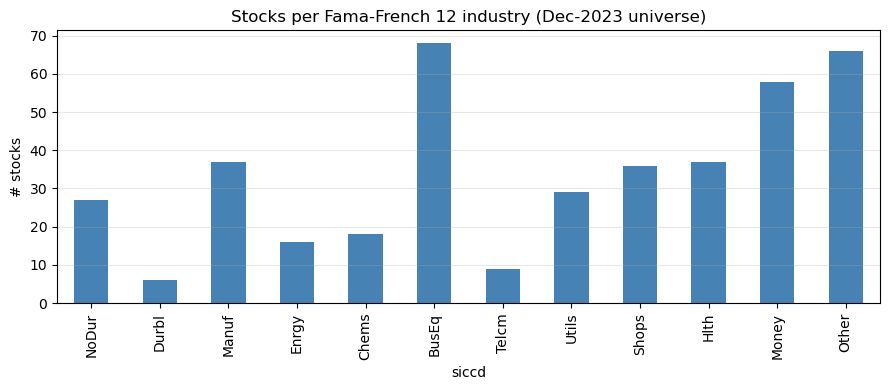

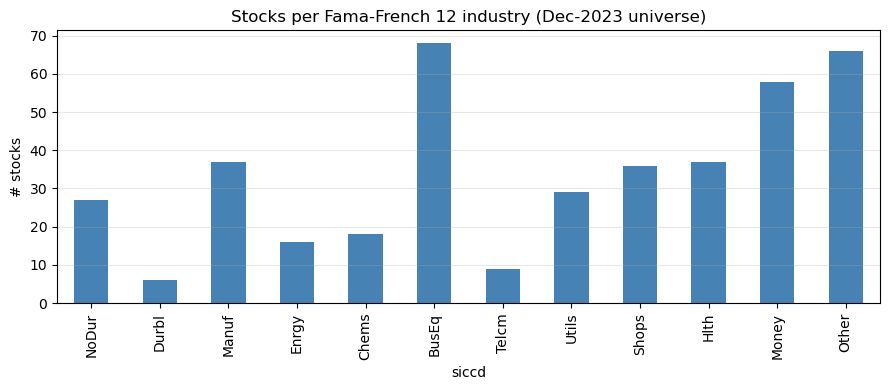

In [2]:
crsp = load_crsp_daily(); cons = load_sp500_constituents()
AS_OF = pd.Timestamp("2023-12-29")
panel = formation_window_panel(AS_OF, crsp=crsp, constituents=cons)
sic = siccd_lookup(list(panel.columns), crsp=crsp, as_of=AS_OF)
fp = build_factor_panel(panel, sic)
print(f"factor panel: {fp.shape[0]} days x {fp.shape[1]} factors")
print("style :", STYLE_FACTORS)
print("indust:", [c for c in fp.columns if c not in STYLE_FACTORS])

ff12 = sic.reindex(panel.columns).map(sic_to_ff12).value_counts().reindex(FF12_INDUSTRIES).dropna()
ax = ff12.plot(kind="bar", color="steelblue")
ax.set_title("Stocks per Fama-French 12 industry (Dec-2023 universe)")
ax.set_ylabel("# stocks"); ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

<a id='3'></a>
## 3. Ridge betas — do the exposures make economic sense?

For each stock we run a **ridge regression** of its daily returns on the 18 factors and keep the
slope coefficients (the "betas") — its exposure vector. We use ridge rather than ordinary least
squares because the factors are correlated; ridge shrinks the estimates so the vectors we cluster
on are stable.

The acid test: the stocks that load hardest on each *industry* factor should actually be in that
industry. Below, the top loaders on four factors — if energy names top the Energy factor and
banks top the Money factor, the method is working.

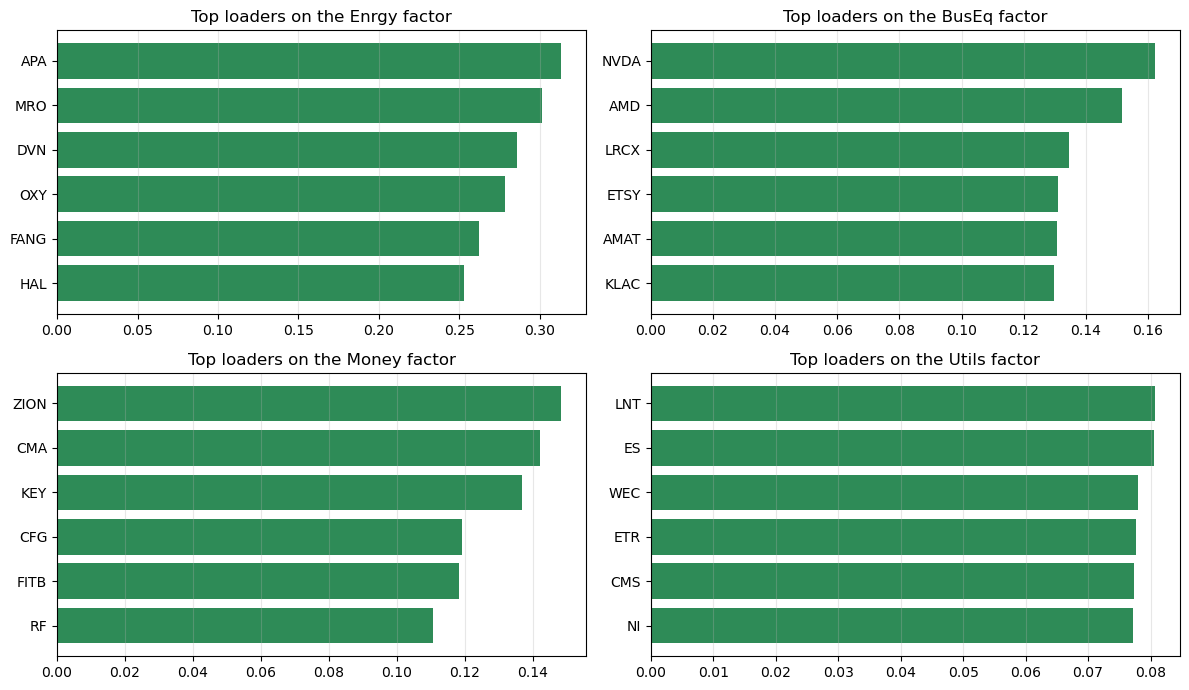

In [3]:
betas = ridge_betas(panel, fp, ridge_alpha=RIDGE_ALPHA)
tk = ticker_lookup(list(panel.columns), crsp=crsp, as_of=AS_OF)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, fac in zip(axes.ravel(), ["Enrgy", "BusEq", "Money", "Utils"]):
    top = betas[fac].sort_values(ascending=False).head(6)[::-1]
    ax.barh([str(tk.get(p, p)) for p in top.index], top.values, color="seagreen")
    ax.set_title(f"Top loaders on the {fac} factor"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

If those panels show oil & gas names on **Enrgy**, semiconductors/tech on **BusEq**, banks on
**Money**, and utilities on **Utils**, the betas are capturing real economic structure — exactly
what we want to cluster on.

<a id='4'></a>
## 4. Factor-beta distance + Dec-2023 clusters

The distance between two stocks = the Euclidean distance between their (standardised) beta
vectors. We standardise each factor so no single one dominates just because its betas happen to
be larger. Then we feed the distance matrix to the same OPTICS clustering used for SSD/PC.

In [4]:
dmat = factor_beta_distance(panel, fp, ridge_alpha=RIDGE_ALPHA)
labels = cluster_optics(dmat, OPTICS_MIN_SAMPLES, OPTICS_XI_FACTOR, OPTICS_MIN_CLUSTER_SIZE)
div = sic.reindex(panel.columns).map(sic_division)
print(f"clusters: {len(set(labels[labels>=0]))} | stocks clustered: {(labels>=0).sum()}/{len(labels)}")
print(f"candidate pairs: {len(clusters_to_pairs(labels))} | purity vs SIC division: {purity_index(labels, div):.3f}")

lab_s = pd.Series(labels, index=panel.columns)
print("\nsample clusters (ticker[industry]):")
for cl in sorted(set(labels[labels>=0]))[:6]:
    members = lab_s.index[lab_s == cl]
    print(f"  cluster {cl:3d}:", ", ".join(f"{tk.get(p,p)}[{sic_to_ff12(sic.get(p))}]" for p in members))

clusters: 78 | stocks clustered: 199/407
candidate pairs: 183 | purity vs SIC division: 0.915

sample clusters (ticker[industry]):
  cluster   0: OTIS[BusEq], IEX[Manuf], AME[BusEq]
  cluster   1: CSX[Other], NSC[Other]
  cluster   2: UPS[Other], EXPD[Other]
  cluster   3: AJG[Money], MMC[Money], ROP[BusEq]
  cluster   4: ADP[BusEq], PAYX[Other], BR[BusEq]
  cluster   5: VMC[Other], MLM[Other]


High purity (~0.9) and industry-coherent clusters confirm the method groups economically
related stocks — the raw material for good pairs.

<a id='5'></a>
## 5. Results vs SSD / PC

Now the payoff. We ran the full backtest with the factor-beta metric and compare to the Phase 1
(SSD) and Phase 2 (PC) results.

In [5]:
def mret(p): return pd.read_parquet(p)["monthly_return"].astype(float)
cells_ = {
    "SSD core":     PHASE2_DIR/"results"/"ssd_core_monthly.parquet",
    "PC core":      PHASE2_DIR/"results"/"pc_core_monthly.parquet",
    "PC + filter":  PHASE2_DIR/"results"/"pc_filtered_monthly.parquet",
    "Factor core":  PHASE2_5_DIR/"results"/"factor_core_monthly.parquet",
    "Factor + filter": PHASE2_5_DIR/"results"/"factor_filtered_monthly.parquet",
}
rows = []
for name, p in cells_.items():
    m = compute_metrics(mret(p))
    rows.append({"cell": name, "Sharpe": round(m.sharpe,3), "Sortino": round(m.sortino,3),
                 "ann_ret": f"{m.ann_return*100:.2f}%", "ann_vol": f"{m.ann_vol*100:.2f}%",
                 "MDD": f"{m.max_drawdown*100:.1f}%"})
print(pd.DataFrame(rows).to_string(index=False))

           cell  Sharpe  Sortino ann_ret ann_vol    MDD
       SSD core   0.589    1.102   3.01%   5.28% -14.3%
        PC core   1.028    2.531   3.41%   3.32%  -5.7%
    PC + filter   0.752    1.396   2.59%   3.48%  -5.9%
    Factor core   1.013    2.598   3.60%   3.55%  -5.9%
Factor + filter   0.858    1.954   4.45%   5.24%  -7.6%


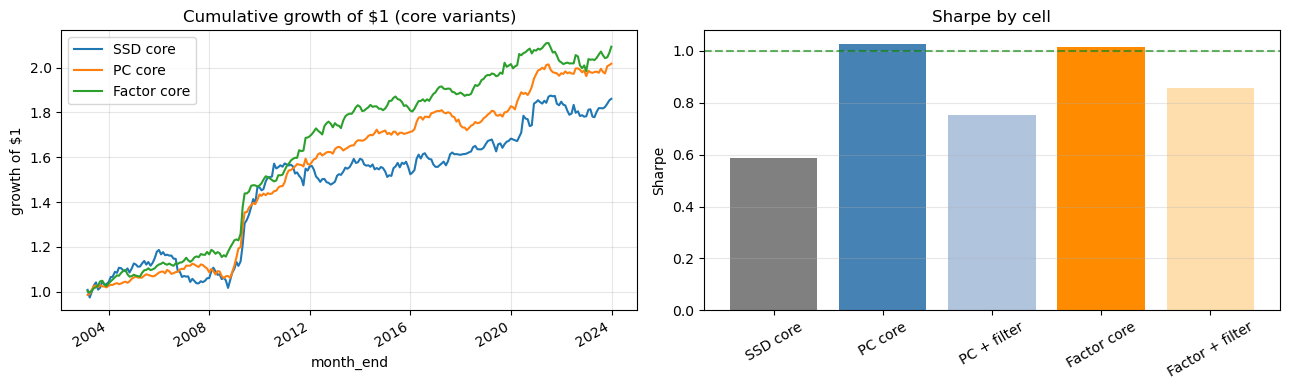

In [6]:
# Equity curves: SSD vs PC vs Factor (core)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
for name, key in [("SSD core","SSD core"),("PC core","PC core"),("Factor core","Factor core")]:
    (1+mret(cells_[key])).cumprod().plot(ax=a1, label=name)
a1.set_title("Cumulative growth of $1 (core variants)"); a1.legend(); a1.grid(alpha=0.3)
a1.set_ylabel("growth of $1")

sh = [compute_metrics(mret(p)).sharpe for p in cells_.values()]
a2.bar(list(cells_.keys()), sh, color=["grey","steelblue","lightsteelblue","darkorange","navajowhite"])
a2.axhline(1.0, ls="--", color="green", alpha=0.6); a2.set_ylabel("Sharpe")
a2.set_title("Sharpe by cell"); a2.tick_params(axis="x", rotation=30); a2.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

**Headline:** factor-beta core reaches Sharpe **1.013** — essentially matching PC core (1.028).
A *structurally different* metric independently reproduces the paper's ~1.0 result, which is
strong evidence the result isn't an artefact of one particular similarity measure. The
filtered variant (0.858) even beats PC+filter (0.752).

<a id='6'></a>
## 6. How the P&L is built

Same diagnostic as Phases 1–2: a small share of trades cleanly revert (big winners); most
force-close at month-end for a tiny loss. Factor-beta should look like PC, not SSD.

In [7]:
t = pd.read_parquet(PHASE2_5_DIR/"results"/"factor_core_trades.parquet")
for reason in ["reversion","force_close","delisting"]:
    s = t[t.exit_reason==reason]["round_trip_return"]
    if len(s): print(f"  {reason:12s} {len(s):5d} ({100*len(s)/len(t):4.1f}%)  mean {s.mean()*1e4:+5.0f} bps")
# within-industry share
sicm = siccd_lookup(crsp=crsp).map(sic_to_ff12)
a, b = t.permno_a.map(sicm).fillna("Other"), t.permno_b.map(sicm).fillna("Other")
print(f"\n  same-industry pairs: {100*(a.values==b.values).mean():.0f}%")

  reversion     1662 ( 8.7%)  mean  +414 bps
  force_close  17343 (91.1%)  mean   -12 bps
  delisting       39 ( 0.2%)  mean  -163 bps

  same-industry pairs: 77%



  same-industry pairs: 77%


<a id='7'></a>
## 7. Conclusion

Factor-beta clustering — clustering stocks by their ridge-estimated exposure to 18 style and
industry factors — **independently reproduces the paper's ~1.0 Sharpe (1.013)**. It is the
group's original contribution and demonstrates that the clustering-based edge generalises across
similarity measures. (In Phase 3 we stress it further, and in Phase 4 we test it out-of-sample.)

*Files:* `src/factors.py`, `src/distances.py::factor_beta_distance`; runners + scorecard under
`phases/phase2_5/`.